In [15]:
# Physics background
# ------------------
#  Fock-darwin spectrum of a quantum dot (energy spectrum in
#  as a function of a magnetic field)
#
# Kwant features highlighted
# --------------------------
#  - Use of `hfrom cmath import exp
import kwant
import numpy as np
from matplotlib import pyplot
# For eigenvalue computation
import scipy.sparse.linalg as sla
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [16]:
a = 1
t = 1.0
r = 10

In [17]:
def make_system(a=1, t=1.0, r=10):
    lat = kwant.lattice.square(a, norbs=1)
    syst = kwant.Builder()

    # Define the quantum dot
    def circle(pos):
        (x, y) = pos
        rsq = x ** 2 + y ** 2
        return rsq < r ** 2

    def hopx(site1, site2, B):
        # The magnetic field is controlled by the parameter B
        y = site1.pos[1]
        return -t * np.exp(-1j * B * y)

    syst[lat.shape(circle, (0, 0))] = 4 * t
    # hoppings in x-direction
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hopx
    # hoppings in y-directions
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = -t
    # It's a closed system for a change, so no leads
    return syst

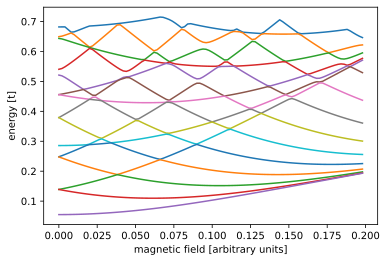

In [18]:
def plot_spectrum(syst, Bfields):

    energies = []
    for B in Bfields:
        # Obtain the Hamiltonian as a sparse matrix
        ham_mat = syst.hamiltonian_submatrix(params=dict(B=B), sparse=True)
        # we only calculate the 15 lowest eigenvalues
        ev = sla.eigsh(ham_mat.tocsc(), k=15, sigma=0,
                       return_eigenvectors=False)
        energies.append(ev)
    pyplot.figure()
    pyplot.plot(Bfields, energies)
    pyplot.xlabel("magnetic field [arbitrary units]")
    pyplot.ylabel("energy [t]")
    pyplot.show()

syst = make_system()
syst = syst.finalized()

# We should observe energy levels that flow towards Landau
# level energies with increasing magnetic field.
plot_spectrum(syst, [iB * 0.002 for iB in range(100)])

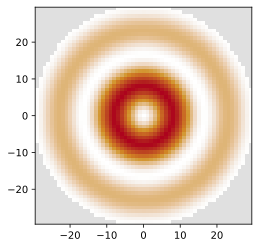

In [19]:
def sorted_eigs(ev):
    evals, evecs = ev
    evals, evecs = map(np.array, zip(*sorted(zip(evals, evecs.transpose()))))
    return evals, evecs.transpose()

def plot_wave_function(syst, B=0.001):
    # Calculate the wave functions in the system.
    ham_mat = syst.hamiltonian_submatrix(sparse=True, params=dict(B=B))
    evals, evecs = sorted_eigs(sla.eigsh(ham_mat.tocsc(), k=20, sigma=0))
    # Plot the probability density of the 10th eigenmode.
    kwant.plotter.map(syst, np.abs(evecs[:, 9])**2,
                      colorbar=False, oversampling=1)

syst = make_system(r=30)
syst = make_system(r=30).finalized()
plot_wave_function(syst);

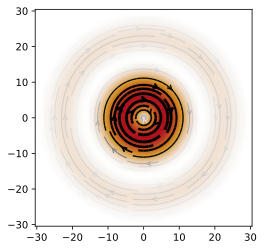

<ipython-input-20-35faea89d937>:9: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  kwant.plotter.current(syst, current, colorbar=False)


In [20]:
def plot_current(syst, B=0.001):
    # Calculate the wave functions in the system.
    ham_mat = syst.hamiltonian_submatrix(sparse=True, params=dict(B=B))
    evals, evecs = sorted_eigs(sla.eigsh(ham_mat.tocsc(), k=20, sigma=0))

    # Calculate and plot the local current of the 10th eigenmode.
    J = kwant.operator.Current(syst)
    current = J(evecs[:, 9], params=dict(B=B))
    kwant.plotter.current(syst, current, colorbar=False)

plot_current(syst);